# HD Task: Machine Learning Mini Research

## Reproduction and Methodological Extension of *An efficient stacking-based ensemble technique for early heart attack prediction*

This notebook contains:
1. a paper-aligned reproduction using the supplied 1,025-row Public Heart Disease dataset;
2. an empirical audit of duplicate-record leakage; and
3. a proposed duplicate-aware, nested-tuned RBF-SVM evaluation framework designed to improve generalisation validity and sensitivity to the positive (heart-disease) class.

**Important reproducibility assumptions.** The paper specifies the dataset, six base classifiers and 5-fold stacking, but does not report every software-level detail such as the exact random seed, the exact train/test ratio, all classifier hyperparameters, or the exact meta-classifier. The published stacking confusion matrix contains 205 test observations, which is 20% of 1,025, so an 80/20 stratified split is used here as an explicit assumption. Logistic Regression is used as the stacking meta-classifier. The dataset has no missing values, so the paper's missing-value imputation step has no numerical effect in this reproduction.

In [2]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.5 MB/s  0:00:00


In [3]:
# 1. Imports and experiment settings
import os, json, warnings, sys
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV, cross_validate)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
                             matthews_corrcoef, classification_report)
from xgboost import XGBClassifier

RANDOM_STATE=42
TEST_SIZE=0.20
OUTPUT_DIR='outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Python:', sys.version.split()[0])

Python: 3.13.9


## 2. Load and inspect the dataset

The paper uses 14 attributes: 13 predictors and the binary `target`. The uploaded dataset is the 1,025-row Kaggle/Public Heart Disease dataset referenced by the paper.

In [4]:
df=pd.read_csv('heart.csv')
expected=['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']
assert list(df.columns)==expected, f'Unexpected columns: {df.columns.tolist()}'

print('Shape:', df.shape)
print('Missing values:', int(df.isna().sum().sum()))
print('Exact duplicate rows:', int(df.duplicated().sum()))
print('Unique rows:', int(df.drop_duplicates().shape[0]))
print('Target distribution:', df['target'].value_counts().to_dict())
display(df.head())

Shape: (1025, 14)
Missing values: 0
Exact duplicate rows: 723
Unique rows: 302
Target distribution: {1: 526, 0: 499}


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## 3. Part 1 - paper-style reproduction

The six individual classifiers are Logistic Regression (LR), Decision Tree (DT), Random Forest (RF), Extreme Gradient Boosting (XGB), Naive Bayes (NB), and K-Nearest Neighbours (KNN). A 5-fold stacking classifier then combines their predictions.

The supplied CSV already encodes categorical variables numerically. All predictors are standardised here before models that benefit from scaling. Tree-based models are not materially affected by monotonic scaling. Because the paper does not publish exact model hyperparameters, standard/default-like settings are used and documented as assumptions.

In [5]:
X=df.drop(columns='target')
y=df['target'].astype(int)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=TEST_SIZE,random_state=RANDOM_STATE,stratify=y)
print('Train:',len(X_train),'Test:',len(X_test))

def scaled(model):
    return Pipeline([('scaler',StandardScaler()),('model',model)])

models={
 'LR': scaled(LogisticRegression(max_iter=2000,random_state=RANDOM_STATE)),
 'DT': DecisionTreeClassifier(random_state=RANDOM_STATE),
 'RF': RandomForestClassifier(n_estimators=100,random_state=RANDOM_STATE,n_jobs=1),
 'XGB': XGBClassifier(n_estimators=100,random_state=RANDOM_STATE,eval_metric='logloss',n_jobs=1),
 'NB': scaled(GaussianNB()),
 'KNN': scaled(KNeighborsClassifier(n_neighbors=5))
}

def metrics_row(name,model,Xtr,ytr,Xte,yte):
    model.fit(Xtr,ytr)
    pred=model.predict(Xte)
    score=model.predict_proba(Xte)[:,1]
    tn,fp,fn,tp=confusion_matrix(yte,pred).ravel()
    return {
      'Model':name,'Accuracy':accuracy_score(yte,pred),'Precision':precision_score(yte,pred),
      'Recall':recall_score(yte,pred),'F1':f1_score(yte,pred),'Specificity':tn/(tn+fp),
      'MCC':matthews_corrcoef(yte,pred),'AUC':roc_auc_score(yte,score),
      'TN':tn,'FP':fp,'FN':fn,'TP':tp
    },pred,score,model

rows=[]; fitted={}; scores={}
for name,m in models.items():
    r,p,s,f=metrics_row(name,m,X_train,y_train,X_test,y_test)
    rows.append(r); fitted[name]=f; scores[name]=s
individual=pd.DataFrame(rows)
display(individual.round(4))

Train: 820 Test: 205


,Model,Accuracy,Precision,Recall,F1,Specificity,MCC,AUC,TN,FP,FN,TP
0,LR,0.8098,0.7619,0.9143,0.8312,0.70,0.6309,0.9298,70,30,9,96
1,DT,0.9854,1.0000,0.9714,0.9855,1.00,0.9712,0.9857,100,0,3,102
2,RF,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000,100,0,0,105
3,XGB,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000,100,0,0,105
4,NB,0.8293,0.8070,0.8762,0.8402,0.78,0.6602,0.9043,78,22,13,92
5,KNN,0.8634,0.8738,0.8571,0.8654,0.87,0.7269,0.9629,87,13,15,90


In [6]:
# 5-fold stacking reproduction
base_estimators=[
 ('lr',LogisticRegression(max_iter=2000,random_state=RANDOM_STATE)),
 ('dt',DecisionTreeClassifier(random_state=RANDOM_STATE)),
 ('rf',RandomForestClassifier(n_estimators=100,random_state=RANDOM_STATE,n_jobs=1)),
 ('xgb',XGBClassifier(n_estimators=100,random_state=RANDOM_STATE,eval_metric='logloss',n_jobs=1)),
 ('nb',GaussianNB()),
 ('knn',KNeighborsClassifier(n_neighbors=5))
]
stack=Pipeline([
 ('scaler',StandardScaler()),
 ('model',StackingClassifier(
     estimators=base_estimators,
     final_estimator=LogisticRegression(max_iter=2000,random_state=RANDOM_STATE),
     cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE),
     stack_method='predict_proba',n_jobs=1
 ))
])
stack_row,stack_pred,stack_score,stack_fitted=metrics_row('Stacking',stack,X_train,y_train,X_test,y_test)
part1=pd.concat([individual,pd.DataFrame([stack_row])],ignore_index=True)
display(part1.round(4))
part1.to_csv(os.path.join(OUTPUT_DIR,'part1_reproduction_results.csv'),index=False)

,Model,Accuracy,Precision,Recall,F1,Specificity,MCC,AUC,TN,FP,FN,TP
0,LR,0.8098,0.7619,0.9143,0.8312,0.70,0.6309,0.9298,70,30,9,96
1,DT,0.9854,1.0000,0.9714,0.9855,1.00,0.9712,0.9857,100,0,3,102
2,RF,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000,100,0,0,105
3,XGB,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000,100,0,0,105
4,NB,0.8293,0.8070,0.8762,0.8402,0.78,0.6602,0.9043,78,22,13,92
5,KNN,0.8634,0.8738,0.8571,0.8654,0.87,0.7269,0.9629,87,13,15,90
6,Stacking,1.0000,1.0000,1.0000,1.0000,1.00,1.0000,1.0000,100,0,0,105


In [7]:
# Published results from Table 11 / Table 12 in the selected paper
published=pd.DataFrame([
 ['LR',0.8439,0.8196,0.9090,0.8620,0.9204],
 ['NB',0.8439,0.8250,0.9000,0.8608,0.9185],
 ['KNN',0.8585,0.8648,0.8727,0.8687,0.9304],
 ['DT',0.9268,0.9702,0.8909,0.9289,0.9702],
 ['RF',0.9268,0.9130,0.9545,0.9333,0.9734],
 ['XGB',0.9073,0.9174,0.9090,0.9132,0.9830],
 ['Stacking',0.9853,1.0000,0.9727,0.9861,0.9880]
],columns=['Model','Paper_Accuracy','Paper_Precision','Paper_Recall','Paper_F1','Paper_AUC'])
comp=published.merge(part1[['Model','Accuracy','Precision','Recall','F1','AUC']],on='Model')
for m in ['Accuracy','Precision','Recall','F1','AUC']:
    comp[m+'_AbsDiff']=(comp[m]-comp['Paper_'+m]).abs()
display(comp.round(4))
comp.to_csv(os.path.join(OUTPUT_DIR,'published_vs_reproduced.csv'),index=False)

,Model,Paper_Accuracy,Paper_Precision,Paper_Recall,Paper_F1,Paper_AUC,Accuracy,Precision,Recall,F1,AUC,Accuracy_AbsDiff,Precision_AbsDiff,Recall_AbsDiff,F1_AbsDiff,AUC_AbsDiff
0,LR,0.8439,0.8196,0.9090,0.8620,0.9204,0.8098,0.7619,0.9143,0.8312,0.9298,0.0341,0.0577,0.0053,0.0308,0.0094
1,NB,0.8439,0.8250,0.9000,0.8608,0.9185,0.8293,0.8070,0.8762,0.8402,0.9043,0.0146,0.0180,0.0238,0.0206,0.0142
2,KNN,0.8585,0.8648,0.8727,0.8687,0.9304,0.8634,0.8738,0.8571,0.8654,0.9629,0.0049,0.0090,0.0156,0.0033,0.0325
3,DT,0.9268,0.9702,0.8909,0.9289,0.9702,0.9854,1.0000,0.9714,0.9855,0.9857,0.0586,0.0298,0.0805,0.0566,0.0155
4,RF,0.9268,0.9130,0.9545,0.9333,0.9734,1.0000,1.0000,1.0000,1.0000,1.0000,0.0732,0.0870,0.0455,0.0667,0.0266
5,XGB,0.9073,0.9174,0.9090,0.9132,0.9830,1.0000,1.0000,1.0000,1.0000,1.0000,0.0927,0.0826,0.0910,0.0868,0.0170
6,Stacking,0.9853,1.0000,0.9727,0.9861,0.9880,1.0000,1.0000,1.0000,1.0000,1.0000,0.0147,0.0000,0.0273,0.0139,0.0120


## 4. Duplicate-overlap audit

A major empirical limitation emerges from the supplied data: 723 of 1,025 rows are exact duplicates. A row-level random split can therefore place identical records on both sides of the train/test boundary. The following audit measures exact test-record overlap with the training set.

In [8]:
train_full=X_train.copy(); train_full['target']=y_train.values
test_full=X_test.copy(); test_full['target']=y_test.values
train_set=set(map(tuple,train_full.to_numpy()))
overlap=sum(tuple(r) in train_set for r in test_full.to_numpy())
overlap_rate=overlap/len(test_full)
print(f'Test rows with an exact duplicate in training: {overlap}/{len(test_full)} ({overlap_rate:.2%})')

duplicate_audit=pd.DataFrame({
 'Metric':['Total rows','Exact duplicate rows','Unique rows','Test rows','Test rows duplicated in train','Overlap rate'],
 'Value':[len(df),df.duplicated().sum(),len(df.drop_duplicates()),len(test_full),overlap,overlap_rate]
})
display(duplicate_audit)
duplicate_audit.to_csv(os.path.join(OUTPUT_DIR,'duplicate_audit.csv'),index=False)

Test rows with an exact duplicate in training: 202/205 (98.54%)


,Metric,Value
0,Total rows,1025.000000
1,Exact duplicate rows,723.000000
2,Unique rows,302.000000
3,Test rows,205.000000
4,Test rows duplicated in train,202.000000
5,Overlap rate,0.985366


## 5. Part 2 - proposed duplicate-aware, nested-tuned RBF-SVM framework

### Motivation
The paper itself notes that false negatives can be especially costly in medical diagnosis. The reproduction audit also shows that near-perfect row-level split performance is not trustworthy when exact duplicates cross the split. The proposed method therefore changes both the data protocol and model-selection protocol:

1. **Deduplicate before model development** so identical records cannot occur in both train and test folds.
2. **Standardise within each training fold** using a scikit-learn Pipeline to avoid preprocessing leakage.
3. **Use an RBF Support Vector Machine with balanced class weights** to model nonlinear boundaries while maintaining sensitivity to the positive class.
4. **Tune `C` and `gamma` only inside inner cross-validation folds**, using recall as the optimisation criterion.
5. **Evaluate performance on untouched outer folds (nested CV)** so hyperparameter selection does not contaminate reported test performance.

This is a methodological redesign of the experimental protocol rather than a simple classifier substitution.

In [7]:
# Deduplicated dataset
unique_df=df.drop_duplicates().reset_index(drop=True)
Xu=unique_df.drop(columns='target'); yu=unique_df['target'].astype(int)
print('Unique dataset shape:',unique_df.shape)
print('Class distribution:',yu.value_counts().to_dict())

# Baseline: paper-style stacking evaluated on the deduplicated data using the same OUTER folds
outer=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
scoring={'Accuracy':'accuracy','Precision':'precision','Recall':'recall','F1':'f1','AUC':'roc_auc'}
baseline_cv=cross_validate(stack,Xu,yu,cv=outer,scoring=scoring,n_jobs=1)
baseline_summary={m:(baseline_cv['test_'+m].mean(),baseline_cv['test_'+m].std()) for m in scoring}
print('Deduplicated stacking baseline:')
for m,(mean,std) in baseline_summary.items(): print(f'{m}: {mean:.4f} +/- {std:.4f}')

Unique dataset shape: (302, 14)
Class distribution: {1: 164, 0: 138}


Deduplicated stacking baseline:
Accuracy: 0.8313 +/- 0.0311
Precision: 0.8267 +/- 0.0408
Recall: 0.8780 +/- 0.0664
F1: 0.8490 +/- 0.0304
AUC: 0.9075 +/- 0.0158


In [8]:
# Nested recall-tuned RBF-SVM
param_grid={
 'svc__C':[0.25,0.5,1,2,4,8],
 'svc__gamma':['scale',0.01,0.03,0.05,0.1]
}
outer=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
nested_rows=[]

for fold,(tr,te) in enumerate(outer.split(Xu,yu),start=1):
    pipe=Pipeline([
      ('scaler',StandardScaler()),
      ('svc',SVC(kernel='rbf',probability=True,class_weight='balanced',random_state=RANDOM_STATE))
    ])
    inner=StratifiedKFold(n_splits=4,shuffle=True,random_state=100+fold)
    search=GridSearchCV(pipe,param_grid,scoring='recall',cv=inner,n_jobs=1)
    search.fit(Xu.iloc[tr],yu.iloc[tr])
    pred=search.predict(Xu.iloc[te])
    score=search.predict_proba(Xu.iloc[te])[:,1]
    nested_rows.append({
      'Fold':fold,
      'Accuracy':accuracy_score(yu.iloc[te],pred),
      'Precision':precision_score(yu.iloc[te],pred),
      'Recall':recall_score(yu.iloc[te],pred),
      'F1':f1_score(yu.iloc[te],pred),
      'AUC':roc_auc_score(yu.iloc[te],score),
      'Best_C':search.best_params_['svc__C'],
      'Best_gamma':search.best_params_['svc__gamma']
    })

nested=pd.DataFrame(nested_rows)
display(nested.round(4))
nested.to_csv(os.path.join(OUTPUT_DIR,'part2_nested_svm_folds.csv'),index=False)

proposed_summary=nested[['Accuracy','Precision','Recall','F1','AUC']].agg(['mean','std']).T
display(proposed_summary.round(4))
proposed_summary.to_csv(os.path.join(OUTPUT_DIR,'part2_nested_svm_summary.csv'))

,Fold,Accuracy,Precision,Recall,F1,AUC,Best_C,Best_gamma
0,1,0.8197,0.8667,0.7879,0.8254,0.8777,0.50,0.01
1,2,0.8525,0.7857,1.0000,0.8800,0.9437,1.00,0.03
2,3,0.8167,0.8000,0.8750,0.8358,0.9152,1.00,0.01
3,4,0.9167,0.8889,0.9697,0.9275,0.9102,0.25,0.01
4,5,0.7833,0.7632,0.8788,0.8169,0.8945,0.25,0.01


,mean,std
Accuracy,0.8378,0.0504
Precision,0.8209,0.0541
Recall,0.9023,0.0844
F1,0.8571,0.0463
AUC,0.9083,0.0247


In [9]:
# Direct fair comparison on the duplicate-free outer-fold protocol
compare_rows=[]
for metric in scoring:
    compare_rows.append({
      'Metric':metric,
      'Deduplicated_Stacking_Mean':baseline_summary[metric][0],
      'Deduplicated_Stacking_SD':baseline_summary[metric][1],
      'Proposed_Nested_SVM_Mean':nested[metric].mean(),
      'Proposed_Nested_SVM_SD':nested[metric].std(ddof=0),
      'Mean_Difference':nested[metric].mean()-baseline_summary[metric][0]
    })
fair_comparison=pd.DataFrame(compare_rows)
display(fair_comparison.round(4))
fair_comparison.to_csv(os.path.join(OUTPUT_DIR,'part2_fair_comparison.csv'),index=False)

,Metric,Deduplicated_Stacking_Mean,Deduplicated_Stacking_SD,Proposed_Nested_SVM_Mean,Proposed_Nested_SVM_SD,Mean_Difference
0,Accuracy,0.8313,0.0311,0.8378,0.0451,0.0064
1,Precision,0.8267,0.0408,0.8209,0.0484,-0.0058
2,Recall,0.8780,0.0664,0.9023,0.0755,0.0242
3,F1,0.8490,0.0304,0.8571,0.0414,0.0081
4,AUC,0.9075,0.0158,0.9083,0.0221,0.0008


## 6. Figures

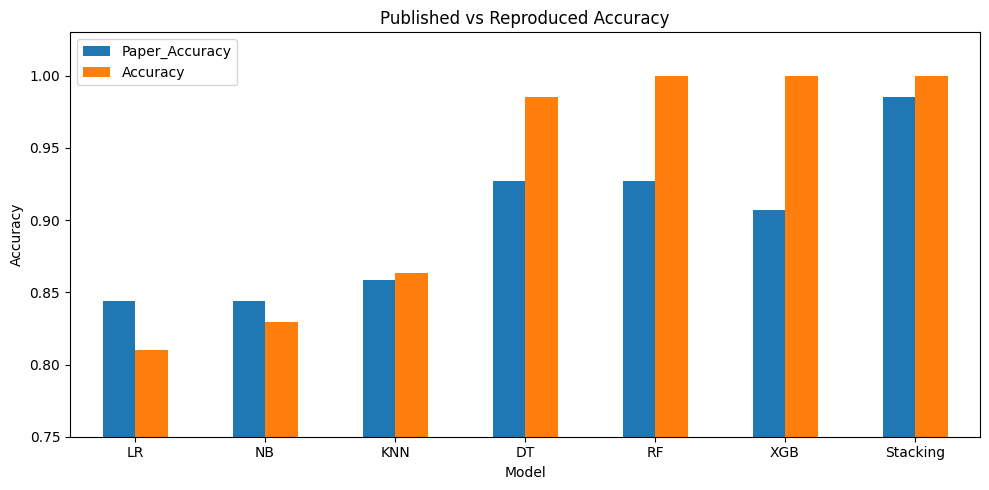

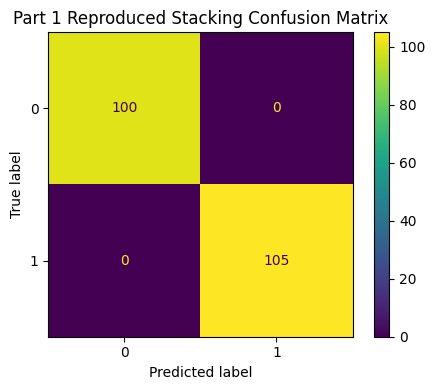

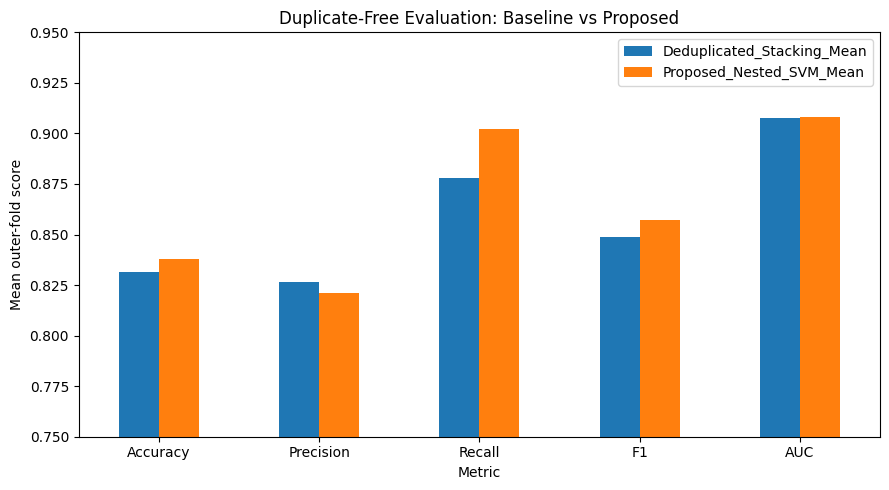

In [10]:
# Figure 1: Published vs reproduced accuracy
acc=comp[['Model','Paper_Accuracy','Accuracy']].set_index('Model')
ax=acc.plot(kind='bar',figsize=(10,5))
ax.set_ylim(0.75,1.03); ax.set_ylabel('Accuracy'); ax.set_title('Published vs Reproduced Accuracy')
plt.xticks(rotation=0); plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,'published_vs_reproduced_accuracy.png'),dpi=220,bbox_inches='tight'); plt.show()

# Figure 2: Part 1 reproduced stacking confusion matrix
fig,ax=plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(y_test,stack_pred,ax=ax)
ax.set_title('Part 1 Reproduced Stacking Confusion Matrix')
plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,'part1_stacking_confusion_matrix.png'),dpi=220,bbox_inches='tight'); plt.show()

# Figure 3: proposed vs baseline on duplicate-free protocol
plot=fair_comparison.set_index('Metric')[['Deduplicated_Stacking_Mean','Proposed_Nested_SVM_Mean']]
ax=plot.plot(kind='bar',figsize=(9,5))
ax.set_ylim(0.75,0.95); ax.set_ylabel('Mean outer-fold score'); ax.set_title('Duplicate-Free Evaluation: Baseline vs Proposed')
plt.xticks(rotation=0); plt.tight_layout(); plt.savefig(os.path.join(OUTPUT_DIR,'part2_baseline_vs_proposed.png'),dpi=220,bbox_inches='tight'); plt.show()

## 7. Reproducibility notes and interpretation

- The paper reports a 98.53% stacking accuracy; this notebook's paper-style split may produce equal or even higher scores because duplicate records cross the split.
- The duplicate-overlap audit is therefore essential to the critical analysis.
- Part 2 intentionally reports lower but more defensible performance after exact duplicates are removed and model selection is nested inside cross-validation.
- The proposed method is tuned for **recall**, because missed positive cases are especially undesirable in medical screening.
- The final report should discuss both predictive performance and experimental validity.
- These models are research demonstrations and are not a clinical diagnostic tool.

In [11]:
# Save compact experiment summary
summary={
 'dataset_rows':int(len(df)),
 'dataset_columns':int(df.shape[1]),
 'duplicates':int(df.duplicated().sum()),
 'unique_rows':int(df.drop_duplicates().shape[0]),
 'test_overlap_count':int(overlap),
 'test_overlap_rate':float(overlap_rate),
 'paper_stacking_accuracy':0.9853,
 'reproduced_stacking_accuracy':float(stack_row['Accuracy']),
 'deduplicated_stacking_cv_accuracy_mean':float(baseline_summary['Accuracy'][0]),
 'proposed_nested_svm_accuracy_mean':float(nested['Accuracy'].mean()),
 'proposed_nested_svm_recall_mean':float(nested['Recall'].mean()),
 'proposed_nested_svm_f1_mean':float(nested['F1'].mean()),
 'proposed_nested_svm_auc_mean':float(nested['AUC'].mean())
}
with open(os.path.join(OUTPUT_DIR,'experiment_summary.json'),'w') as f: json.dump(summary,f,indent=2)
print(json.dumps(summary,indent=2))

{
  "dataset_rows": 1025,
  "dataset_columns": 14,
  "duplicates": 723,
  "unique_rows": 302,
  "test_overlap_count": 202,
  "test_overlap_rate": 0.9853658536585366,
  "paper_stacking_accuracy": 0.9853,
  "reproduced_stacking_accuracy": 1.0,
  "deduplicated_stacking_cv_accuracy_mean": 0.8313114754098361,
  "proposed_nested_svm_accuracy_mean": 0.8377595628415302,
  "proposed_nested_svm_recall_mean": 0.9022727272727273,
  "proposed_nested_svm_f1_mean": 0.8571310722507952,
  "proposed_nested_svm_auc_mean": 0.9082641895141895
}
